云模型代码，参考邱老师文章  
《Three-dimensional Velocity Fields of the Solar Filament Eruptions Detected by CHASE》

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial

In [ ]:
#数据准备
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam[50:90]#序号50-90是从Ha线性蓝翼到红翼，线心的±1A

参考区域和目标区域的选取

宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流选取的位置  y:1521.49,x:794.70


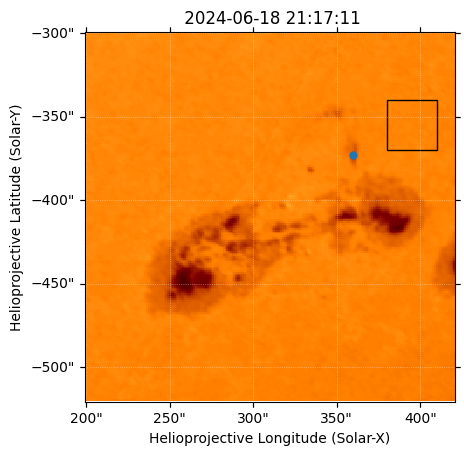

In [5]:
hawing = rsm[1].data[-10, :, :]
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
ax=fig.add_subplot(projection=sub_hawing_map)
sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )

#point1是宁静区左下角
point1=SkyCoord(Tx=380*u.arcsec,Ty=-370*u.arcsec,frame=hawing_map.coordinate_frame)
xpix1,ypix1=hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')
#point2是宁静区右上角
point2=SkyCoord(Tx=410*u.arcsec,Ty=-340*u.arcsec,frame=hawing_map.coordinate_frame)
xpix2,ypix2=hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')
#point3是喷流选一个点
point3=SkyCoord(Tx=360*u.arcsec,Ty=-373*u.arcsec,frame=hawing_map.coordinate_frame)
xpix3,ypix3=hawing_map.world_to_pixel(point3)
sub_hawing_map.draw_quadrangle(point1,top_right=point2,axes=ax,edgecolor='black')
ax.plot_coord(point3,marker='o',markersize=5)
print(f'喷流选取的位置  y:{xpix3.value:.2f},x:{ypix3.value:.2f}')

In [ ]:
#待拟合参数
I0=rsm[1].data[50:90,797:826,1540:1569].mean(axis=(1,2))
I=rsm[1].data[50:90,1521,795]

单云模型公式  
$\tau(\lambda)=\tau_0 \exp \left( -\frac{(\lambda - \lambda_0 - \frac{v \lambda_0}{c})^2 }{W^2}\right)$  
$I=I_0 e^{- \tau}+S(1-e^{-\tau})$  
$S,\tau_0,v,W$是待拟合参数

In [11]:
def single_cloud(lam,S,tau0,v,W,I0):
    lam0=6562.8
    c=299792
    tau=tau0*np.exp(-((lam-lam0-v*lam0/c)**2)/W**2)
    I=I0*np.exp(-tau)+S*(1-np.exp(-tau))
    return I

In [25]:
print('S_initial=',np.mean(I0))

S_initial= 593.5882282996433


S=1353.89, tau0=0.15, v=30.03, W=0.39


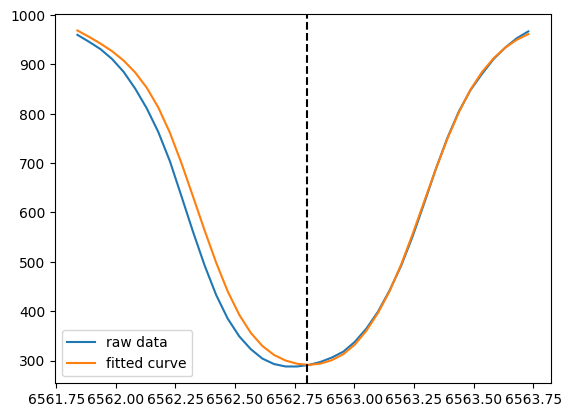

In [26]:
#初值
paras=np.zeros((3,4))
#第0列是S_initial,min,max
paras[0,0],paras[1,0],paras[2,0]=np.mean(I0),0,20000
#第1列是\tau0_initial,min,max
paras[0,1],paras[1,1],paras[2,1]=0.2,0.001,100
#第2列是v_initial,min,max
paras[0,2],paras[1,2],paras[2,2]=3,-100,200
#第3列是多普勒展宽W
paras[0,3],paras[1,3],paras[2,3]=0.5,0.01,10

#曲线拟合
single_cloud_par=partial(single_cloud,I0=I0)
popt,pcov=curve_fit(single_cloud_par,lam,I,p0=paras[0,:],
                    bounds=(paras[1,:],paras[2,:]),maxfev=2000)

#输出拟合结果
S_fit,tau0_fit,v_fit,W_fit=popt
print('S={:.2f}, tau0={:.2f}, v={:.2f}, W={:.2f}'.format(S_fit,tau0_fit,v_fit,W_fit))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,single_cloud_par(lam,*popt),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

双云模型  
$\tau_L(\lambda)=\tau_{0L} \exp \left(- \frac{(\lambda -\lambda_0 -\frac{v_L\lambda_0}{c})^2}{W_L^2} \right)$  
$\tau_U(\lambda)=\tau_{0U} \exp \left(- \frac{(\lambda -\lambda_0 -\frac{v_U\lambda_0}{c})^2}{W_U^2} \right)$  
$I=I_0 e^{-(\tau_L+\tau_U)} + S_L(1-e^{-\tau_L})e^{-\tau_U}+S_U(1-e^{-\tau_U})$  
U,L的下表分别代表上层和下层的云  
待拟合的参数为$S_L,S_U,\tau_{0L},\tau_{0U},v_L,v_U,W_L,W_U$

In [27]:
def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

SL=1004.88,初值是593.59,范围是[0.00,20000.00], SU=239.45,初值是593.59,范围是[0.00,20000.00]
tau0L=0.89,初值是0.20,范围是[0.00,100.00], tau0U=0.53,初值是0.20,范围是[0.00,100.00]
vL=56.45,初值是10.00,范围是[0.00,100.00], vU=-2.44,初值是-10.00,范围是[-100.00,0.00]
WL=0.75,初值是0.50,范围是[0.01,10.00], WU=0.43,初值是0.50,范围是[0.01,10.00]


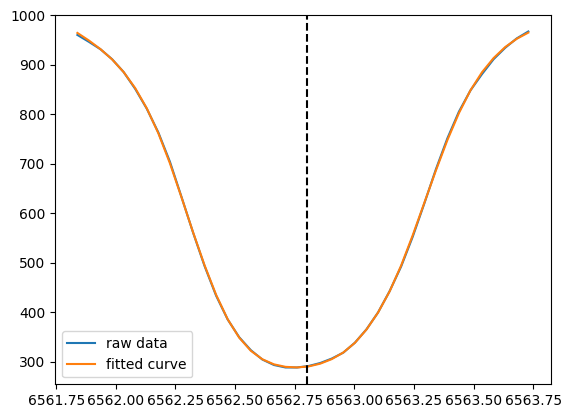

In [33]:
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=10,0,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-10,-100,0
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

__<font color=cyan>双云模型拟合的效果非常好！！！</font>__  
记录一下参数  
I0=rsm[1].data[50:90,797:826,1540:1569].mean(axis=(1,2))  
I=rsm[1].data[50:90,1521,795]  
SL=1004.88,初值是593.59,范围是[0.00,20000.00], SU=239.45,初值是593.59,范围是[0.00,20000.00]  
tau0L=0.89,初值是0.20,范围是[0.00,100.00], tau0U=0.53,初值是0.20,范围是[0.00,100.00]  
vL=56.45,初值是10.00,范围是[0.00,100.00], vU=-2.44,初值是-10.00,范围是[-100.00,0.00]  
WL=0.75,初值是0.50,范围是[0.01,10.00], WU=0.43,初值是0.50,范围是[0.01,10.00]  


SL=248.06,初值是593.59,范围是[0.00,20000.00], SU=1013.60,初值是593.59,范围是[0.00,20000.00]
tau0L=0.51,初值是0.20,范围是[0.00,100.00], tau0U=0.66,初值是0.20,范围是[0.00,100.00]
vL=-3.02,初值是-10.00,范围是[-100.00,0.00], vU=49.21,初值是10.00,范围是[0.00,100.00]
WL=0.43,初值是0.50,范围是[0.01,10.00], WU=0.61,初值是0.50,范围是[0.01,10.00]


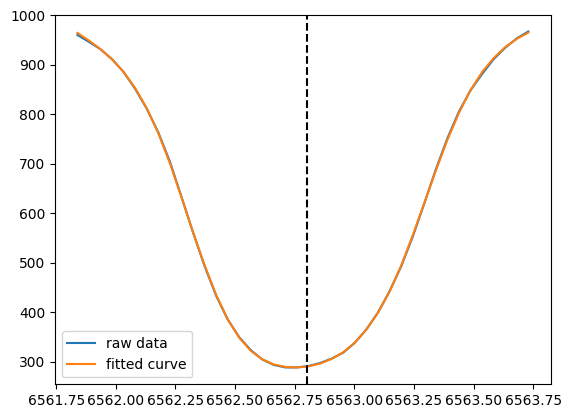

In [ ]:
#我试一下如果上下层云反过来呢？好像拟合的也不错，速度不会差太多
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=-10,-100,0
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=10,0,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()